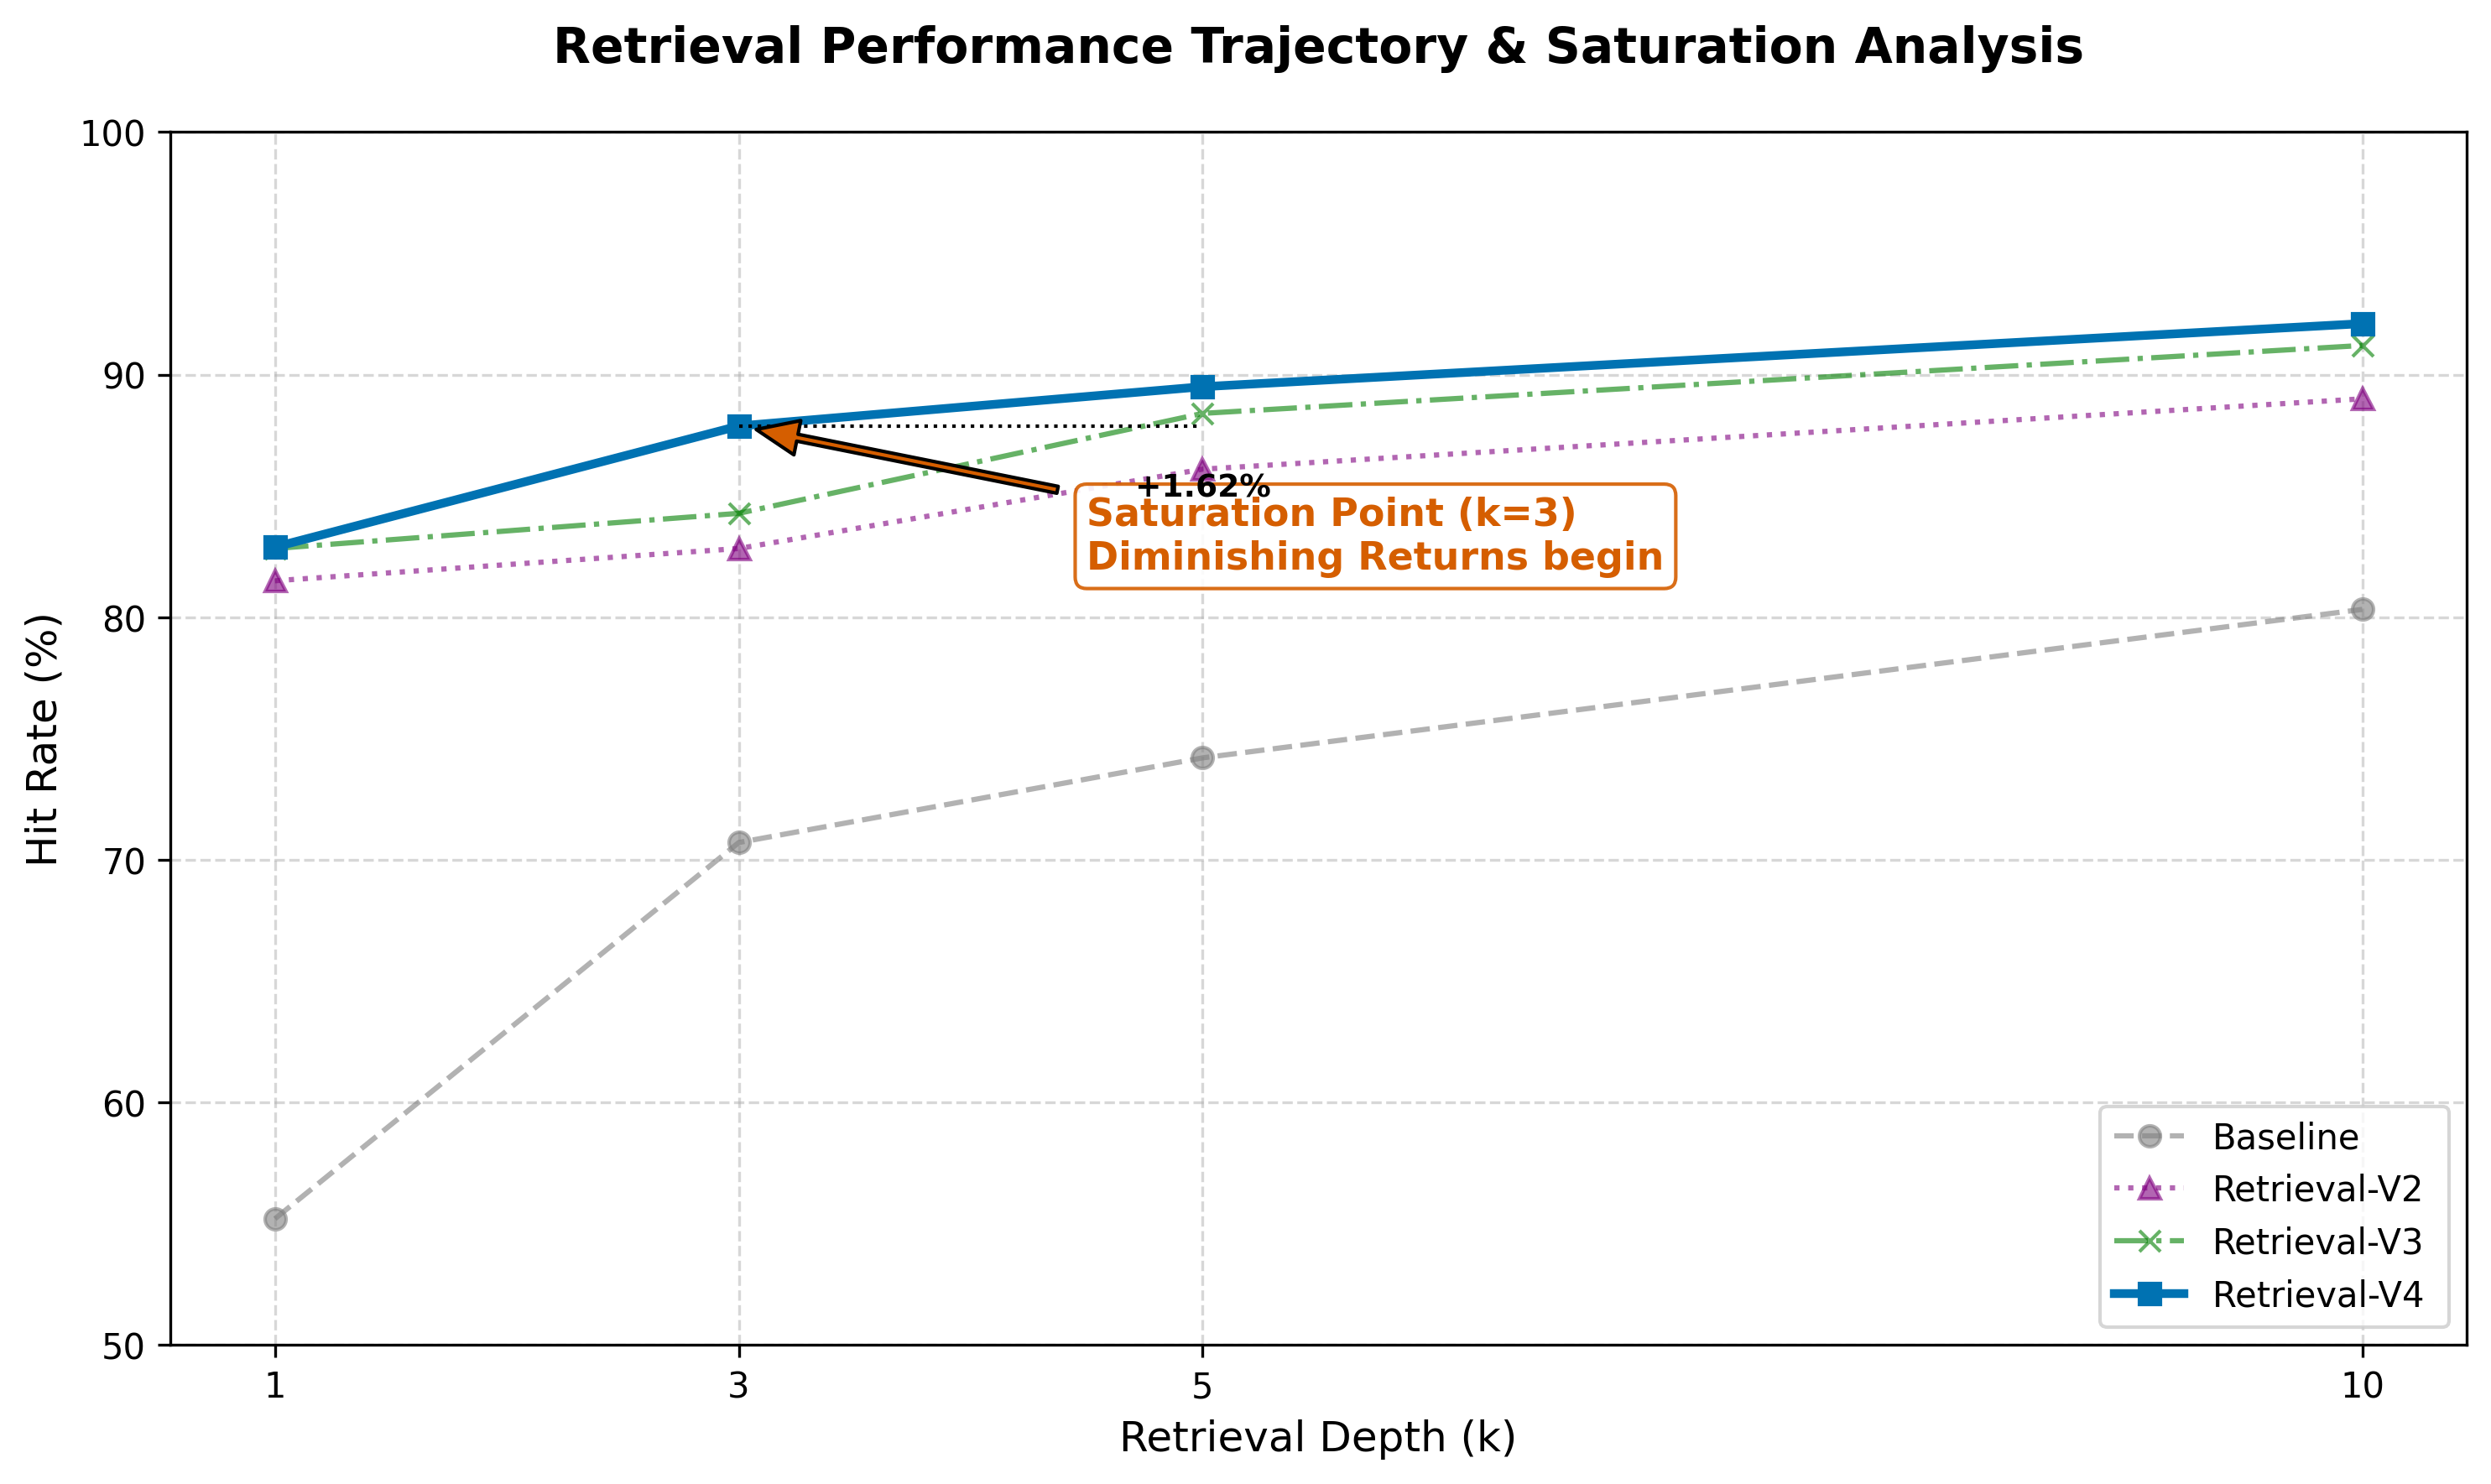

In [3]:
import matplotlib.pyplot as plt

# 1. Define the Data (Full Table IX)
k_values = [1, 3, 5, 10]

# Hit Rates (%)
baseline = [55.20, 70.71, 74.20, 80.32]
retrieval_v2 = [81.50, 82.83, 86.10, 89.00]
retrieval_v3 = [82.83, 84.28, 88.40, 91.20]
retrieval_v4 = [82.89, 87.88, 89.50, 92.10]

# 2. Setup the Plot
plt.figure(figsize=(10, 6), dpi=300)

# 3. Plot All Lines
plt.plot(k_values, baseline, marker='o', linestyle='--', color='gray', alpha=0.6, label='Baseline')
plt.plot(k_values, retrieval_v2, marker='^', linestyle=':', color='purple', alpha=0.6, label='Retrieval-V2')
plt.plot(k_values, retrieval_v3, marker='x', linestyle='-.', color='green', alpha=0.6, label='Retrieval-V3')
plt.plot(k_values, retrieval_v4, marker='s', linestyle='-', color='#0072B2', linewidth=2.5, label='Retrieval-V4 ')

# 4. Add the Saturation Point Annotation (The "Elbow")
# We highlight the point (3, 87.88) on the V4 line
plt.annotate('Saturation Point (k=3)\nDiminishing Returns begin', 
             xy=(3, 87.88), 
             xytext=(4.5, 82),
             arrowprops=dict(facecolor='#D55E00', shrink=0.05, width=2, headwidth=10),
             fontsize=11, fontweight='bold', color='#D55E00',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#D55E00", alpha=0.9))

# 5. Highlight the Small Gain to k=5
plt.plot([3, 5], [87.88, 87.88], color='black', linestyle=':', linewidth=1) # Horizontal Ref
plt.annotate('+1.62%', xy=(5, 88.5), xytext=(5, 85),
             ha='center', fontsize=9, fontweight='bold', color='black')

# 6. Formatting for Academic Publication
plt.title('Retrieval Performance Trajectory & Saturation Analysis', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Retrieval Depth (k)', fontsize=12)
plt.ylabel('Hit Rate (%)', fontsize=12)
plt.xticks(k_values) # Only show relevant k values
plt.ylim(50, 100)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', frameon=True, fontsize=10)

# 7. Show/Save
plt.tight_layout()
plt.show()

# plt.savefig('saturation_curve_full.png', dpi=300)

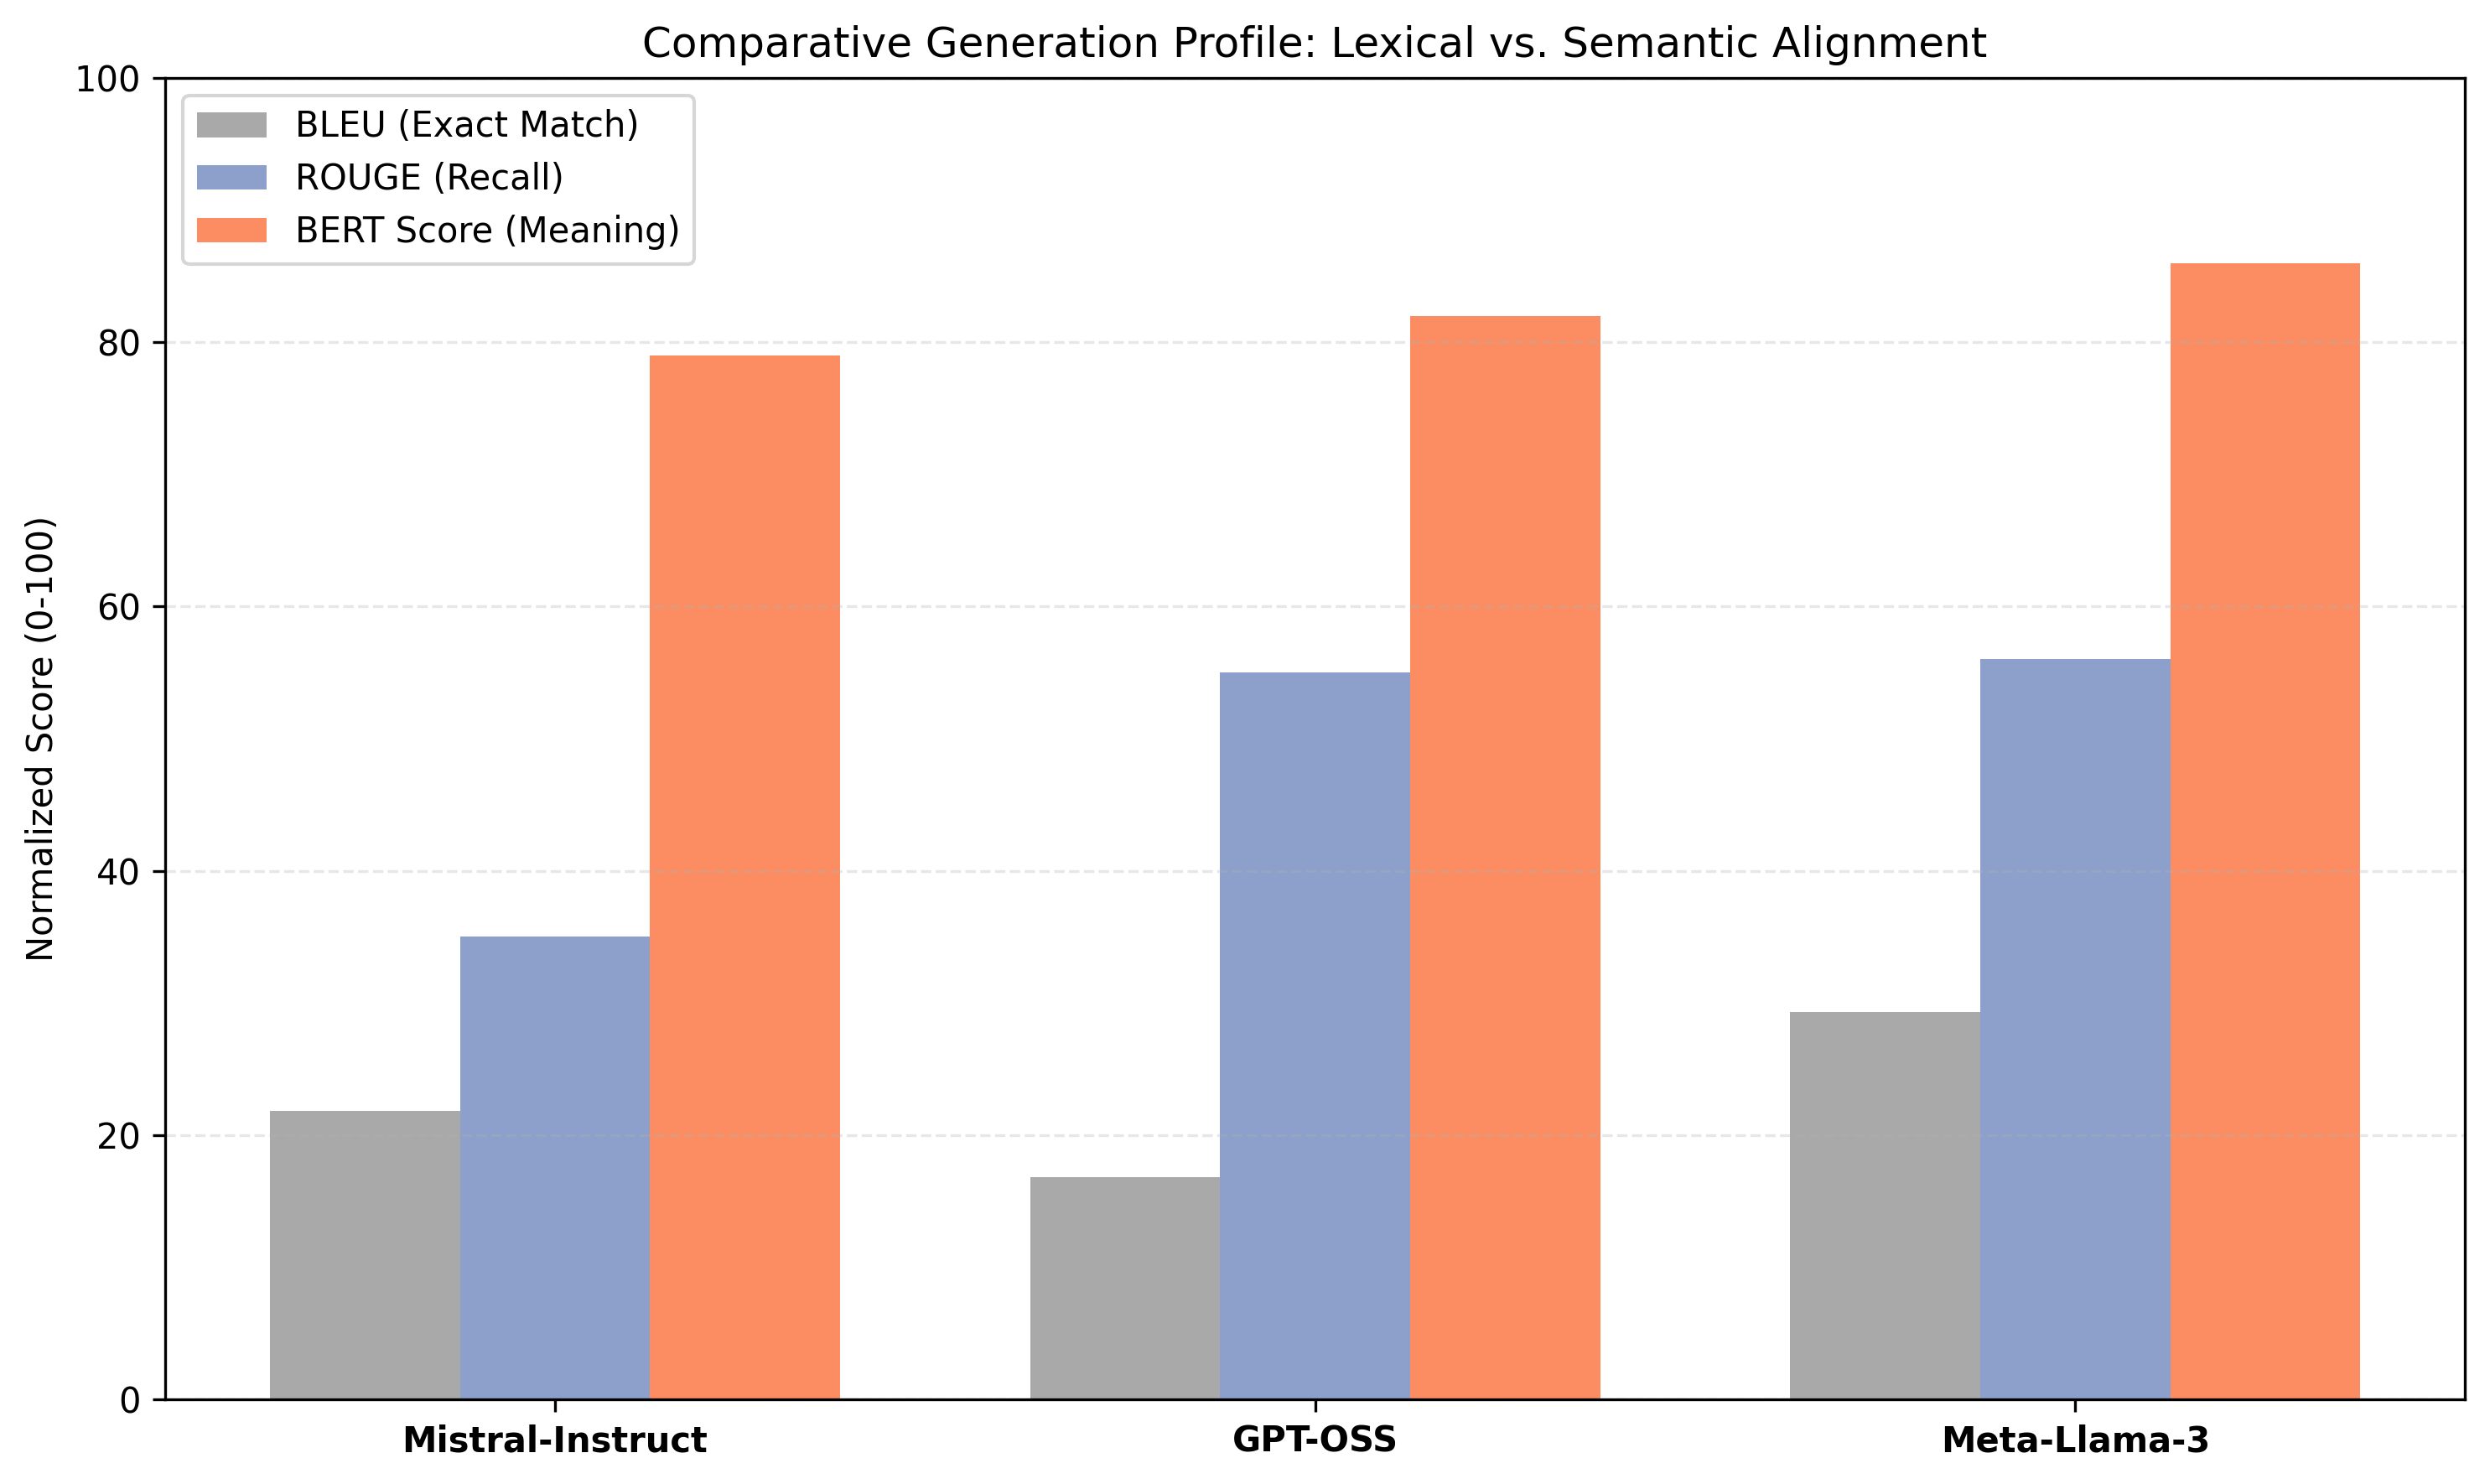

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['Mistral-Instruct', 'GPT-OSS', 'Meta-Llama-3']
# Normalizing all scores to a 0-100 scale for direct visual comparison
bleu = [21.8, 16.8, 29.28]
rouge = [35.0, 55.0, 56.0]  # Converted from 0.35 -> 35.0
bert = [79.0, 82.0, 86.0]   # Converted from 0.79 -> 79.0

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Create Bars
bar1 = ax.bar(x - width, bleu, width, label='BLEU (Exact Match)', color='#A9A9A9') # Grey for rigid matching
bar2 = ax.bar(x, rouge, width, label='ROUGE (Recall)', color='#8da0cb')         # Light Blue for recall
bar3 = ax.bar(x + width, bert, width, label='BERT Score (Meaning)', color='#fc8d62') # Orange for semantic meaning

# Formatting
ax.set_ylabel('Normalized Score (0-100)')
ax.set_title('Comparative Generation Profile: Lexical vs. Semantic Alignment')
ax.set_xticks(x)
ax.set_xticklabels(models, fontweight='bold')
ax.legend()
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Add Annotation for the "Paraphrasing Gap"


plt.tight_layout()
plt.show()

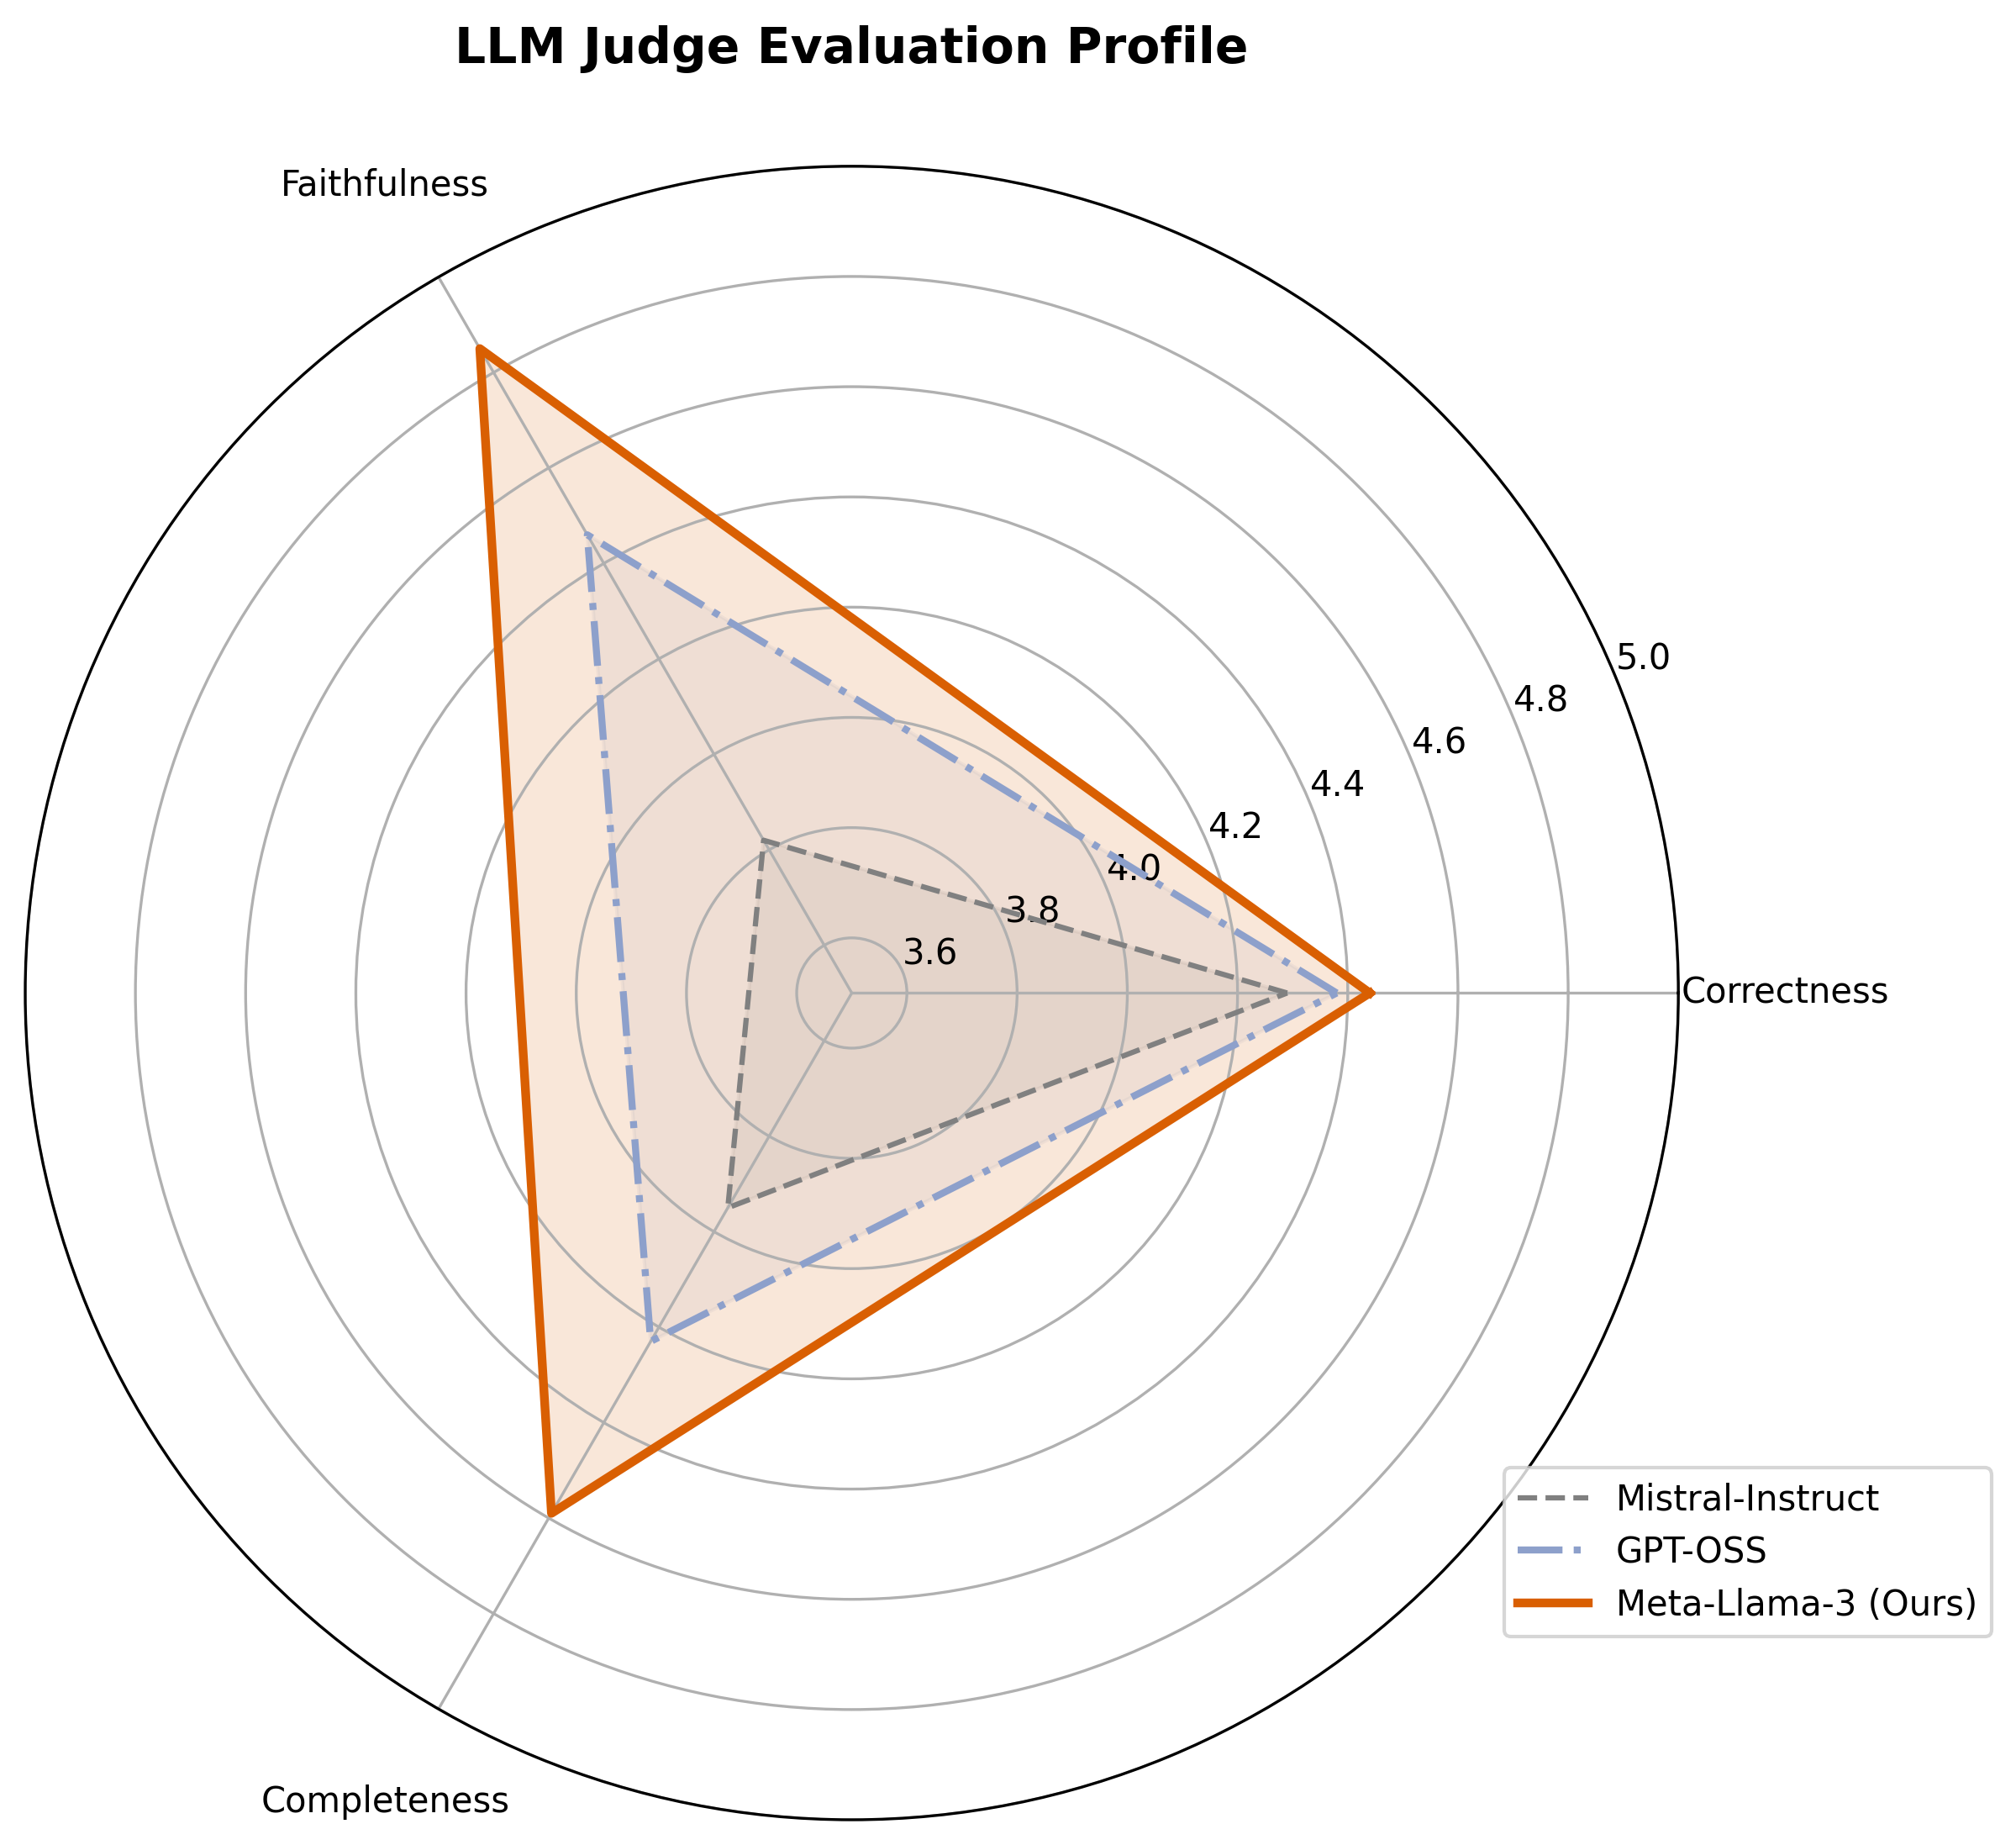

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Data from Table IIX
categories = ['Correctness', 'Faithfulness', 'Completeness']
categories = [*categories, categories[0]] # Close the loop for the radar chart

# Scores
mistral = [4.29, 3.82, 3.95, 4.29]
gpt_oss = [4.38, 4.46, 4.23, 4.38]
llama = [4.44, 4.85, 4.59, 4.44]

label_loc = np.linspace(start=0, stop=2 * np.pi, num=len(mistral))

plt.figure(figsize=(8, 8), dpi=300)
ax = plt.subplot(polar=True)

# Plot Mistral (The "Dented" Triangle)
ax.plot(label_loc, mistral, label='Mistral-Instruct', linestyle='--', color='gray', linewidth=1.5)
ax.fill(label_loc, mistral, color='gray', alpha=0.1)

# Plot GPT-OSS
ax.plot(label_loc, gpt_oss, label='GPT-OSS', linestyle='-.', color='#8da0cb', linewidth=2)
ax.fill(label_loc, gpt_oss, color='#8da0cb', alpha=0.1)

# Plot Llama-3 (The "Perfect" Triangle)
ax.plot(label_loc, llama, label='Meta-Llama-3 (Ours)', linestyle='-', color='#d95f02', linewidth=2.5)
ax.fill(label_loc, llama, color='#d95f02', alpha=0.15)

# Formatting
ax.set_title('LLM Judge Evaluation Profile', size=14, weight='bold', y=1.05)
lines, labels = plt.thetagrids(np.degrees(label_loc[:-1]), labels=['Correctness', 'Faithfulness', 'Completeness'])
ax.tick_params(pad=20) # Push labels out slightly for readability

# Zoom in on the relevant scale (3.5 to 5.0) to make differences visible
ax.set_ylim(3.5, 5.0)

plt.legend(loc='lower right', bbox_to_anchor=(1.2, 0.1))
plt.tight_layout()
plt.show()